# Part 3: Fuzzy Inference System (FIS) Modelling
This notebook defines the calibrated membership functions using data percentiles, sets up the 8-rule base, runs three simulations (Sebelum, Log-Transform, and Rank-Based), and exports the results and control surfaces.

In [1]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

os.makedirs('report/figures', exist_ok=True)
os.makedirs('output', exist_ok=True)

## 1. Load Data & Compute Empirical Percentiles
We compute the percentiles for the different normalizations to quantitatively calibrate the fuzzy membership functions.

In [2]:
df = pd.read_csv('dataset/product_features_clean.csv')

percentiles = [.25, .33, .50, .67, .75]
stats = df[['stok_level_log', 'jumlah_penjualan_log', 'stok_level_rank', 'jumlah_penjualan_rank', 'avg_rating']].describe(percentiles=percentiles)
print('=== EMPIRES PERCENTILES TABLE ===')
print(stats.loc[['25%', '33%', '50%', '67%', '75%']])

=== EMPIRES PERCENTILES TABLE ===
     stok_level_log  jumlah_penjualan_log  stok_level_rank  \
25%       78.027972              3.453204        26.016062   
33%       82.679401              6.444504        32.781699   
50%       88.556749             11.443251        49.805305   
67%       93.555496             17.320599        71.623266   
75%       96.546796             21.972028        71.623266   

     jumlah_penjualan_rank  avg_rating  
25%              28.376734    3.800000  
33%              28.376734    3.945761  
50%              50.194695    4.188679  
67%              67.218301    4.400000  
75%              73.983938    4.500000  


## 2. Define Fuzzy Control Simulation Functions
We define a helper function to set up the MFs using the data percentiles and run the FIS for all products.

In [3]:
def run_fis_model(df, stok_col, penjualan_col, MFs_stok, MFs_penjualan, P50_rating):
    # Define Antecedents and Consequent
    stok = ctrl.Antecedent(np.arange(0, 101, 1), 'stok_level')
    penjualan = ctrl.Antecedent(np.arange(0, 101, 1), 'jumlah_penjualan')
    rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'avg_rating')
    diskon = ctrl.Consequent(np.arange(0, 51, 1), 'besar_diskon')

    # Calibrate MFs
    stok['Sedikit'] = fuzz.trimf(stok.universe, [0, 0, MFs_stok['P33']])
    stok['Sedang'] = fuzz.trimf(stok.universe, [MFs_stok['P25'], MFs_stok['P50'], MFs_stok['P75']])
    stok['Banyak'] = fuzz.trimf(stok.universe, [MFs_stok['P67'], 100, 100])

    penjualan['Rendah'] = fuzz.trimf(penjualan.universe, [0, 0, MFs_penjualan['P33']])
    penjualan['Sedang'] = fuzz.trimf(penjualan.universe, [MFs_penjualan['P25'], MFs_penjualan['P50'], MFs_penjualan['P75']])
    penjualan['Tinggi'] = fuzz.trimf(penjualan.universe, [MFs_penjualan['P67'], 100, 100])

    rating['Buruk'] = fuzz.trimf(rating.universe, [1.0, 1.0, P50_rating])
    rating['Baik'] = fuzz.trimf(rating.universe, [P50_rating, 5.0, 5.0])

    diskon['Kecil'] = fuzz.trimf(diskon.universe, [0, 0, 20])
    diskon['Sedang'] = fuzz.trimf(diskon.universe, [10, 25, 40])
    diskon['Besar'] = fuzz.trimf(diskon.universe, [30, 50, 50])

    # Define 8 rules
    rule1 = ctrl.Rule(stok['Banyak'] & penjualan['Rendah'], diskon['Besar'])
    rule2 = ctrl.Rule(stok['Sedikit'] & penjualan['Tinggi'], diskon['Kecil'])
    rule3 = ctrl.Rule(rating['Buruk'], diskon['Besar'])
    rule4 = ctrl.Rule(stok['Sedang'] & penjualan['Sedang'], diskon['Sedang'])
    rule5 = ctrl.Rule(stok['Banyak'] & penjualan['Sedang'], diskon['Sedang'])
    rule6 = ctrl.Rule(stok['Sedang'] & penjualan['Rendah'], diskon['Sedang'])
    rule7 = ctrl.Rule(stok['Sedikit'] & penjualan['Sedang'], diskon['Kecil'])
    rule8 = ctrl.Rule(rating['Baik'] & penjualan['Tinggi'], diskon['Kecil'])

    discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
    discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

    discounts = []
    for idx, row in df.iterrows():
        discount_sim.input['stok_level'] = row[stok_col]
        discount_sim.input['jumlah_penjualan'] = row[penjualan_col]
        discount_sim.input['avg_rating'] = row['avg_rating']
        try:
            discount_sim.compute()
            val = discount_sim.output['besar_diskon']
        except:
            val = 25.0 # default fallback
        discounts.append(val)
    return discounts, discount_sim

## 3. Run Simulation for Three Scenarios
We execute the FIS for three scenarios:
1. **Sebelum (Heuristic)**: Heuristic MFs (0, 20, 30, 40, 50, 60, 80, 100) and raw min-max scaled variables.
2. **Log-Transform Model**: Percentile calibrated MFs and log-transformed variables.
3. **Rank-Based Model**: Percentile calibrated MFs and rank-normalized variables.

In [4]:
# A. Sebelum (Heuristic)
def run_orig_model(df):
    stok = ctrl.Antecedent(np.arange(0, 101, 1), 'stok_level')
    penjualan = ctrl.Antecedent(np.arange(0, 101, 1), 'jumlah_penjualan')
    rating = ctrl.Antecedent(np.arange(1.0, 5.1, 0.1), 'avg_rating')
    diskon = ctrl.Consequent(np.arange(0, 51, 1), 'besar_diskon')

    stok['Sedikit'] = fuzz.trimf(stok.universe, [0, 0, 40])
    stok['Sedang'] = fuzz.trimf(stok.universe, [20, 50, 80])
    stok['Banyak'] = fuzz.trimf(stok.universe, [60, 100, 100])

    penjualan['Rendah'] = fuzz.trimf(penjualan.universe, [0, 0, 40])
    penjualan['Sedang'] = fuzz.trimf(penjualan.universe, [20, 50, 80])
    penjualan['Tinggi'] = fuzz.trimf(penjualan.universe, [60, 100, 100])

    rating['Buruk'] = fuzz.trimf(rating.universe, [1.0, 1.0, 3.0])
    rating['Baik'] = fuzz.trimf(rating.universe, [3.0, 5.0, 5.0])

    diskon['Kecil'] = fuzz.trimf(diskon.universe, [0, 0, 20])
    diskon['Sedang'] = fuzz.trimf(diskon.universe, [10, 25, 40])
    diskon['Besar'] = fuzz.trimf(diskon.universe, [30, 50, 50])

    rule1 = ctrl.Rule(stok['Banyak'] & penjualan['Rendah'], diskon['Besar'])
    rule2 = ctrl.Rule(stok['Sedikit'] & penjualan['Tinggi'], diskon['Kecil'])
    rule3 = ctrl.Rule(rating['Buruk'], diskon['Besar'])
    rule4 = ctrl.Rule(stok['Sedang'] & penjualan['Sedang'], diskon['Sedang'])
    rule5 = ctrl.Rule(stok['Banyak'] & penjualan['Sedang'], diskon['Sedang'])
    rule6 = ctrl.Rule(stok['Sedang'] & penjualan['Rendah'], diskon['Sedang'])
    rule7 = ctrl.Rule(stok['Sedikit'] & penjualan['Sedang'], diskon['Kecil'])
    rule8 = ctrl.Rule(rating['Baik'] & penjualan['Tinggi'], diskon['Kecil'])

    discount_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8])
    discount_sim = ctrl.ControlSystemSimulation(discount_ctrl)

    discounts = []
    for idx, row in df.iterrows():
        # normalize jumlah_penjualan to [0, 100]
        discount_sim.input['stok_level'] = row['stok_level_orig']
        discount_sim.input['jumlah_penjualan'] = row['jumlah_penjualan_orig']
        discount_sim.input['avg_rating'] = row['avg_rating']
        try:
            discount_sim.compute()
            val = discount_sim.output['besar_diskon']
        except:
            val = 25.0
        discounts.append(val)
    return discounts

df['besar_diskon_sebelum'] = run_orig_model(df)

In [5]:
# B. Calibrated Log-Transform Model
MFs_stok_log = {'P25': stats.loc['25%', 'stok_level_log'], 'P33': stats.loc['33%', 'stok_level_log'], 'P50': stats.loc['50%', 'stok_level_log'], 'P67': stats.loc['67%', 'stok_level_log'], 'P75': stats.loc['75%', 'stok_level_log']}
MFs_penjualan_log = {'P25': stats.loc['25%', 'jumlah_penjualan_log'], 'P33': stats.loc['33%', 'jumlah_penjualan_log'], 'P50': stats.loc['50%', 'jumlah_penjualan_log'], 'P67': stats.loc['67%', 'jumlah_penjualan_log'], 'P75': stats.loc['75%', 'jumlah_penjualan_log']}
P50_rating = stats.loc['50%', 'avg_rating']

df['besar_diskon_log'], sim_log = run_fis_model(
    df, 'stok_level_log', 'jumlah_penjualan_log', MFs_stok_log, MFs_penjualan_log, P50_rating
)

In [6]:
# C. Calibrated Rank-Based Model
MFs_stok_rank = {'P25': stats.loc['25%', 'stok_level_rank'], 'P33': stats.loc['33%', 'stok_level_rank'], 'P50': stats.loc['50%', 'stok_level_rank'], 'P67': stats.loc['67%', 'stok_level_rank'], 'P75': stats.loc['75%', 'stok_level_rank']}
MFs_penjualan_rank = {'P25': stats.loc['25%', 'jumlah_penjualan_rank'], 'P33': stats.loc['33%', 'jumlah_penjualan_rank'], 'P50': stats.loc['50%', 'jumlah_penjualan_rank'], 'P67': stats.loc['67%', 'jumlah_penjualan_rank'], 'P75': stats.loc['75%', 'jumlah_penjualan_rank']}

df['besar_diskon_rank'], sim_rank = run_fis_model(
    df, 'stok_level_rank', 'jumlah_penjualan_rank', MFs_stok_rank, MFs_penjualan_rank, P50_rating
)

# Export results
df.to_csv('dataset/fis_discount_results.csv', index=False)
print('FIS simulations completed and saved to dataset/fis_discount_results.csv')

FIS simulations completed and saved to dataset/fis_discount_results.csv


## 4. Plot 3D Control Surfaces for Chosen Model (Rank-Based)
We map out the 3D surface plot to visualize the control dynamics of the calibrated Rank-Based system.

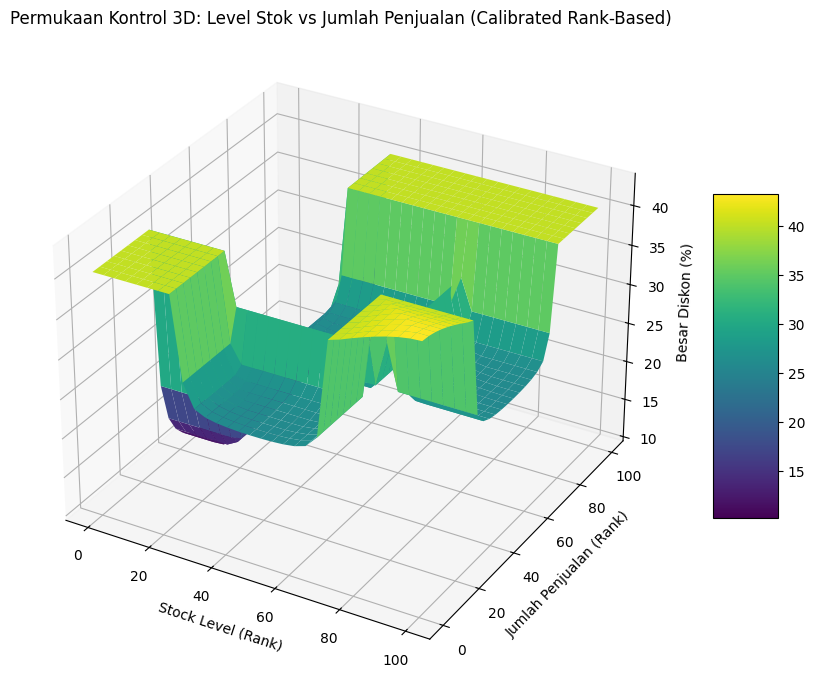

In [7]:
# Grid for Stock vs Sales (Rating = 4.0)
x_range = np.linspace(0, 100, 30)
y_range = np.linspace(0, 100, 30)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = np.zeros_like(x_grid)

for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        sim_rank.input['stok_level'] = x_grid[i, j]
        sim_rank.input['jumlah_penjualan'] = y_grid[i, j]
        sim_rank.input['avg_rating'] = 4.0
        try:
            sim_rank.compute()
            z_grid[i, j] = sim_rank.output['besar_diskon']
        except:
            z_grid[i, j] = 25.0

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis', edgecolor='none')
ax.set_title('Permukaan Kontrol 3D: Level Stok vs Jumlah Penjualan (Calibrated Rank-Based)')
ax.set_xlabel('Stock Level (Rank)')
ax.set_ylabel('Jumlah Penjualan (Rank)')
ax.set_zlabel('Besar Diskon (%)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()
plt.savefig('report/figures/modelling_surface_stok_penjualan.png', dpi=150)
plt.savefig('output/modelling_surface_stok_penjualan.png', dpi=150)
plt.show()

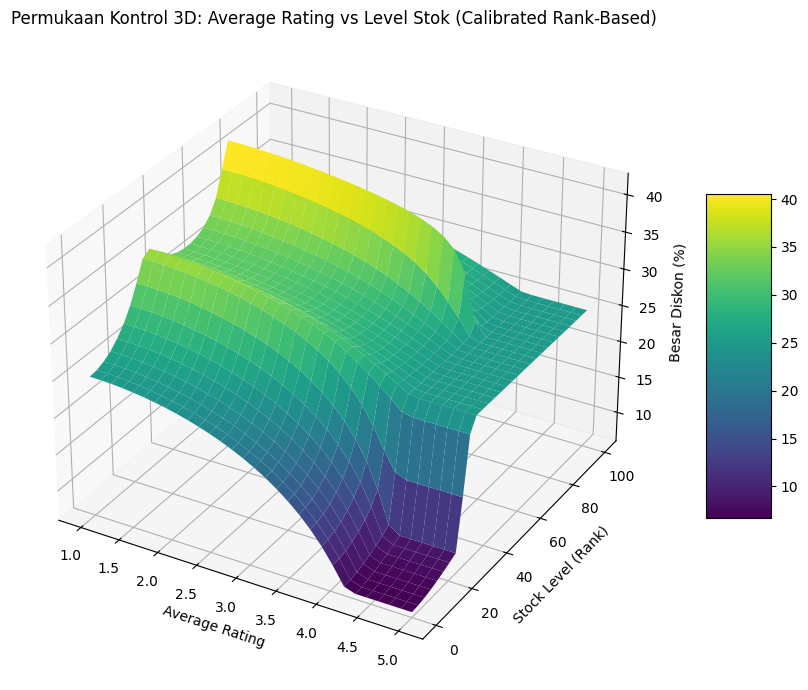

In [8]:
# Grid for Rating vs Stock (Sales = 50.0)
x_range = np.linspace(1.0, 5.0, 30)
y_range = np.linspace(0, 100, 30)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = np.zeros_like(x_grid)

for i in range(x_grid.shape[0]):
    for j in range(x_grid.shape[1]):
        sim_rank.input['avg_rating'] = x_grid[i, j]
        sim_rank.input['stok_level'] = y_grid[i, j]
        sim_rank.input['jumlah_penjualan'] = 50.0
        try:
            sim_rank.compute()
            z_grid[i, j] = sim_rank.output['besar_diskon']
        except:
            z_grid[i, j] = 25.0

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(x_grid, y_grid, z_grid, cmap='viridis', edgecolor='none')
ax.set_title('Permukaan Kontrol 3D: Average Rating vs Level Stok (Calibrated Rank-Based)')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Stock Level (Rank)')
ax.set_zlabel('Besar Diskon (%)')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()
plt.savefig('report/figures/modelling_surface_rating_stok.png', dpi=150)
plt.savefig('output/modelling_surface_rating_stok.png', dpi=150)
plt.show()